Pertemuan 5
Nama    : ARSINA
NIM     : 230401010199
Kelas   : IF405

Langkah 1: Load & Inspect Dataset
Muat dataset Tips menggunakan sns.load_dataset(). Tampilkan shape, dtypes, dan .describe().

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Set style global Seaborn
sns.set_theme(style='whitegrid', palette='Set2')

# Load dataset Tips
df = sns.load_dataset('tips')

print('=== Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== 5 Baris Pertama ===')
print(df.head())

print('\n=== Statistik Deskriptif ===')
print(df.describe().round(2))

=== Shape ===
(244, 7)

=== Data Types ===
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

=== 5 Baris Pertama ===
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

=== Statistik Deskriptif ===
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


Deskripsi Dataset :
Dataset Tpis terdiri dari 244 baris dan 7 kolom yang merekam data tagihan di sebuah restoran.

Langkah 2: Setup Figure Layout

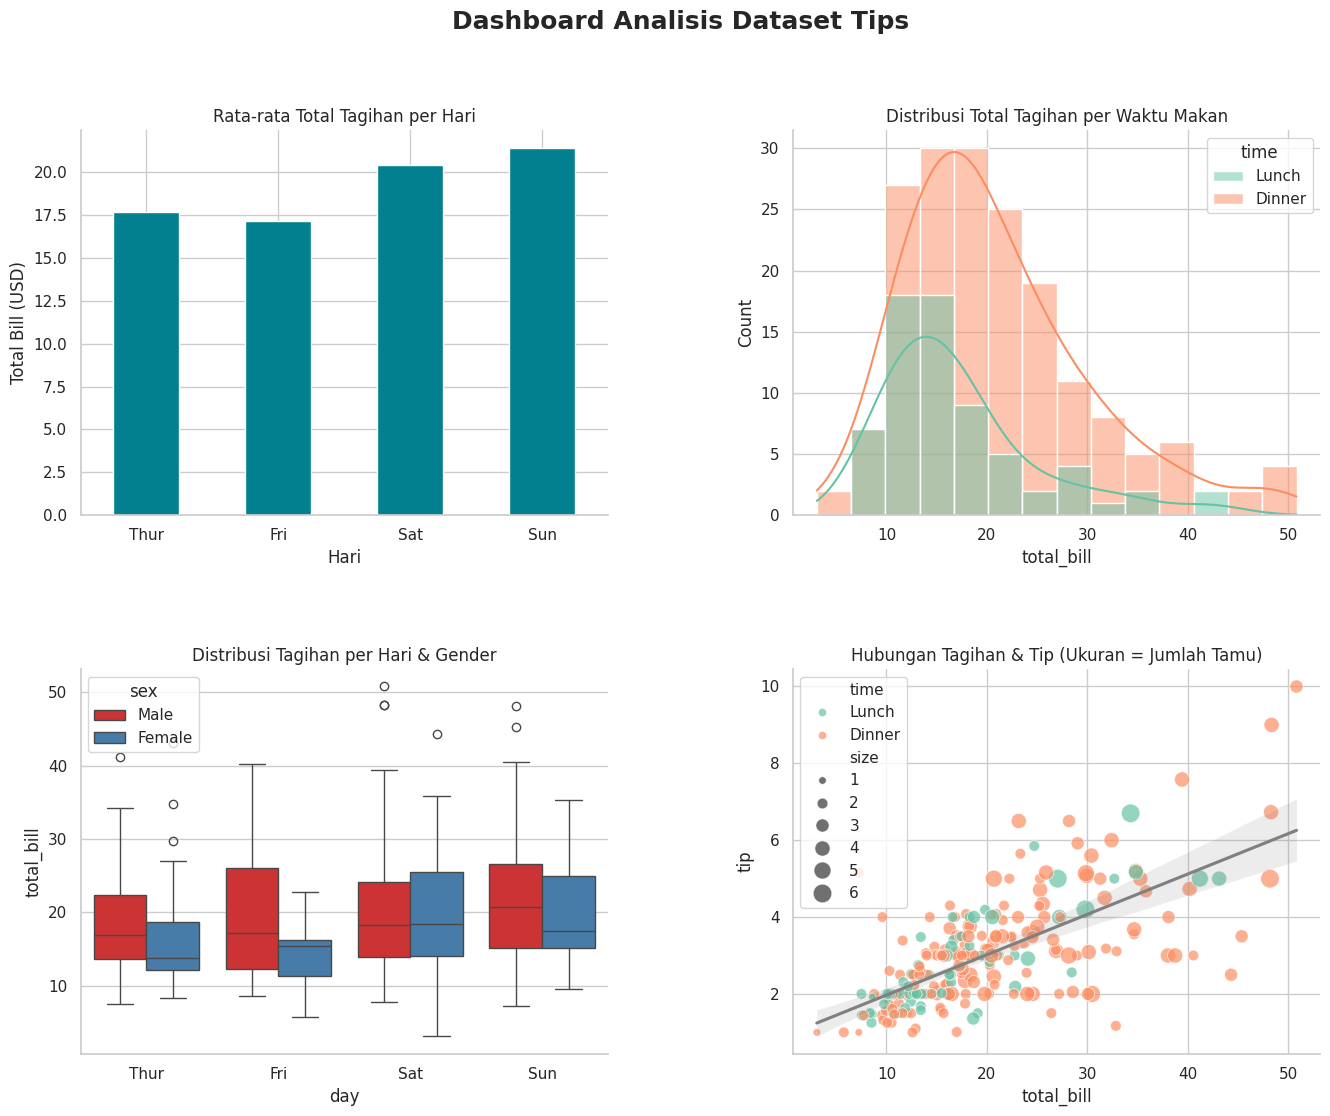

Dashboard tersimpan sebagai dashboard_tips.png


In [2]:
# === 2. SETUP FIGURE LAYOUT ===
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips', 
            fontsize=18, fontweight='bold', y=0.98)

# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig, 
                      hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0]) # kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # kanan bawah

# ========== 3. GRAFIK 1: Bar Chart ==========
# Menambahkan observed=False untuk menghilangkan warning
avg_by_day = df.groupby('day', observed=False)['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090', 
                edgecolor='white')

ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False)

# ========== 4. GRAFIK 2: Histogram + KDE ==========
sns.histplot(data=df, x='total_bill', hue='time', 
             kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top', 'right']].set_visible(False)

# ========== 5. GRAFIK 3: Boxplot ==========
sns.boxplot(data=df, x='day', y='total_bill', 
          hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top', 'right']].set_visible(False)

# ========== 6. GRAFIK 4: Scatter Plot ==========
sns.scatterplot(data=df, x='total_bill', y='tip', 
               hue='time', size='size', sizes=(30, 180),
               palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip', 
            scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top', 'right']].set_visible(False)

# ========== 7. EKSPOR ==========
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show() 
print('Dashboard tersimpan sebagai dashboard_tips.png')

Analisis Visualisasi Dataset Tips
1. Bar Chart: Rata-rata Total Tagihan per Hari
Analisis: Grafik menunjukkan variasi rata-rata pengeluaran pelanggan di restoran dari hari Kamis hingga Minggu. Data mengonfirmasi bahwa puncak pengeluaran rata-rata terjadi pada akhir pekan, yakni hari Sabtu dan Minggu (mencapai sekitar $21), dibandingkan hari kerja.

Implikasi & Tindakan: Tingginya rata-rata tagihan di akhir pekan menandakan adanya peningkatan volume transaksi atau nilai pesanan. Disarankan bagi manajemen untuk mengoptimalkan ketersediaan stok menu populer dan menambah tenaga kerja operasional pada hari-hari tersebut untuk menjaga kualitas layanan.

2. Histogram & KDE: Distribusi Tagihan per Waktu Makan
Analisis: Visualisasi ini membandingkan pola pengeluaran antara waktu makan siang (Lunch) dan malam (Dinner). Sesi Dinner menunjukkan distribusi yang lebih luas dengan skewness positif, yang berarti terdapat transaksi dengan nilai yang sangat tinggi. Sebaliknya, Lunch cenderung memiliki pola pengeluaran yang lebih rendah dan terkonsentrasi.

Implikasi & Tindakan: Perbedaan pola ini dapat dimanfaatkan untuk strategi pemasaran. Untuk Lunch, restoran dapat memperkenalkan paket hemat atau menu bundling guna meningkatkan rata-rata transaksi. Untuk Dinner, perlu ada upaya untuk memahami segmen pelanggan premium yang berkontribusi pada nilai tagihan tinggi.

3. Boxplot: Distribusi Tagihan Berdasarkan Hari dan Gender
Analisis: Secara umum, pelanggan pria menunjukkan median pengeluaran yang lebih tinggi di hampir semua hari. Hari Sabtu mencatatkan variasi tagihan yang paling besar sekaligus memiliki outlier (nilai ekstrem) terbanyak, baik pada pelanggan pria maupun wanita.

Implikasi & Tindakan: Perlu ada kajian lebih mendalam mengenai faktor pendorong perbedaan ini, seperti jumlah tamu per meja atau jenis pesanan. Data outlier pada akhir pekan bisa menjadi target untuk program loyalitas pelanggan karena merepresentasikan segmen dengan daya beli tinggi.

4. Scatter Plot: Korelasi antara Tagihan dan Tip
Analisis: Terdapat hubungan positif yang kuat antara jumlah tagihan dan nominal tip yang diberikan; semakin besar total tagihan, cenderung diikuti dengan peningkatan tip. Selain itu, terlihat bahwa meja dengan jumlah tamu yang lebih banyak (titik lebih besar) sering kali berkontribusi pada tagihan yang lebih tinggi.

Implikasi & Tindakan: Mengingat tagihan yang lebih tinggi berbanding lurus dengan tip, strategi upselling (menawarkan tambahan menu atau minuman) menjadi kunci untuk meningkatkan pendapatan bagi staf restoran. Sebagai evaluasi kinerja, ada baiknya juga menghitung persentase tip secara proporsional untuk memahami tingkat kepuasan pelanggan secara lebih objektif.